Dataset Shape: (150, 4)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Classes: ['setosa' 'versicolor' 'virginica']

================ MODEL PERFORMANCE ================

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.933      0.933   0.933     0.933
                SVM     0.967      0.970   0.967     0.967
      Decision Tree     0.933      0.933   0.933     0.933

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90

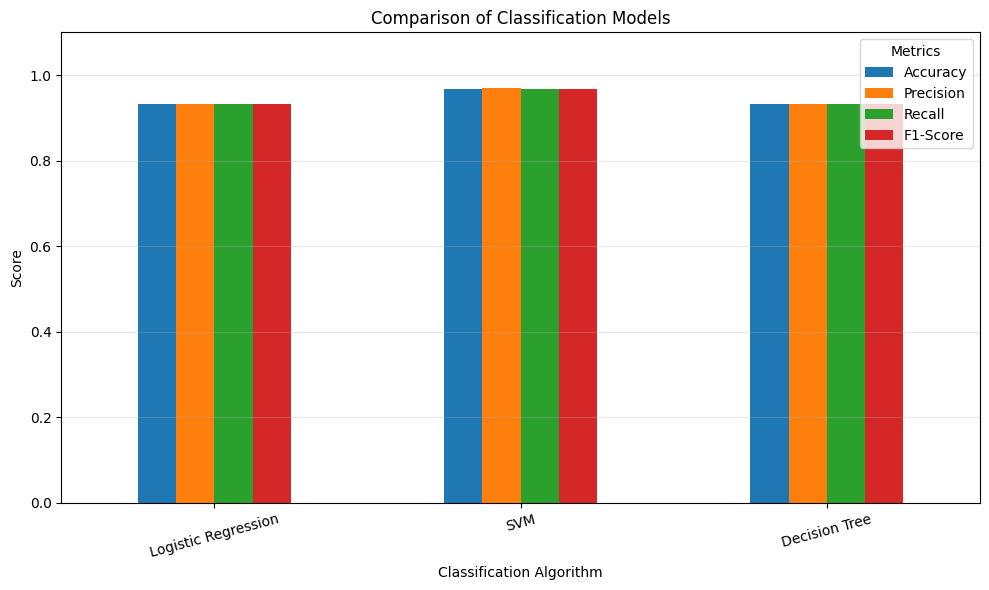

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report)
iris = load_iris()
X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names)
y = iris.target
print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())
print("\nClasses:", iris.target_names)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "SVM": SVC(
        kernel="rbf",
        random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5)}
results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average="weighted")
    recall = recall_score(
        y_test, y_pred, average="weighted")
    f1 = f1_score(
        y_test, y_pred, average="weighted")
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1})
    predictions[name] = y_pred
results_df = pd.DataFrame(results)
print("\n================ MODEL PERFORMANCE ================\n")
print(
    results_df.round(3).to_string(index=False))
for name, y_pred in predictions.items():
    print("\n====================================================")
    print(name)
    print("====================================================")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names))
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()]
print("\n================ BEST MODEL =================")
print("Model     :", best_model["Model"])
print("Accuracy  :", round(best_model["Accuracy"], 3))
print("Precision :", round(best_model["Precision"], 3))
print("Recall    :", round(best_model["Recall"], 3))
print("F1-Score  :", round(best_model["F1-Score"], 3))
print("================================================")
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
results_plot = results_df.set_index("Model")[metrics]
results_plot.plot(
    kind="bar",
    figsize=(10, 6))
plt.title("Comparison of Classification Models")
plt.xlabel("Classification Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()